# 01 — ETL Pipeline: Online Retail II Dataset

**Module:** Principles of Data Science (7144)  
**Institution:** Coventry University — NIBM Campus  
**Dataset:** Online Retail II — [Kaggle Source](https://www.kaggle.com/datasets/mathchi/online-retail-ii-data-set-from-ml-repository)  

---

## ETL Process Requirements

| # | Requirement |
|---|-------------|
| 1 | Perform a complete **Extract, Transform, Load (ETL)** process |
| 2 | **Clean** missing values, remove inconsistencies, and handle outliers |
| 3 | **Transform and integrate** datasets for analysis |
| 4 | **Document** the entire ETL pipeline clearly (tools, steps, assumptions) |

---

## Tools & Technologies

| Tool | Version | Purpose |
|------|---------|---------|
| Python | 3.11+ | Core programming language |
| Pandas | 2.x | Data manipulation and I/O |
| NumPy | 1.26+ | Numerical operations and IQR bounds |
| Matplotlib | 3.8+ | Outlier visualisation |
| Seaborn | 0.13+ | Statistical visualisation |
| KaggleHub | latest | Programmatic dataset download |
| Git / GitHub | — | Version control and collaboration |

---

## Pipeline Overview

```
┌─────────────┐    ┌──────────────────────────────────────┐    ┌──────────────────┐
│   EXTRACT   │───▶│             TRANSFORM                │───▶│      LOAD        │
│             │    │  Step 1: Remove cancellations        │    │                  │
│ Kaggle API  │    │  Step 2: Remove duplicates           │    │ cleaned_retail   │
│ Download    │    │  Step 3: Drop null Customer IDs      │    │ _data.csv        │
│ 541,909 rows│    │  Step 4: Filter invalid Qty/Price    │    │ 333,234 rows     │
└─────────────┘    │  Step 5: IQR outlier removal         │    └──────────────────┘
                   │  Step 6: Feature engineering         │
                   └──────────────────────────────────────┘
```

---
## ⬇ STEP 0 — Install Required Libraries

Run this cell **once** to install all dependencies.

In [3]:
# Run this cell once to install all required libraries
import subprocess, sys

packages = ['kagglehub', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'openpyxl']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All libraries installed!')

All libraries installed!


---
## ⬇ STEP 1 — EXTRACT: Download Dataset from Kaggle

**Method:** Programmatic download using `kagglehub` library.  
**Source:** https://www.kaggle.com/datasets/mathchi/online-retail-ii-data-set-from-ml-repository  
**Encoding:** ISO-8859-1 (Latin-1) — required to preserve special characters in product descriptions.

**Assumption A1:** The dataset file `Year 2010-2011.csv` inside the downloaded archive is the primary data source for this analysis, covering transactions from December 2010 to December 2011.

In [4]:
# ============================================================
# STEP 1: EXTRACT — Download and Load Data from Kaggle
# ============================================================
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── 1A. Download from Kaggle ─────────────────────────────────
print('Downloading dataset from Kaggle...')
download_path = kagglehub.dataset_download(
    'mathchi/online-retail-ii-data-set-from-ml-repository'
)
print(f'Downloaded to: {download_path}')

# ── 1B. Find the CSV file ────────────────────────────────────
csv_file = None
for root, dirs, files in os.walk(download_path):
    for f in files:
        if '2010-2011' in f and f.endswith('.csv'):
            csv_file = os.path.join(root, f)
            break
    # Also check for .xlsx files
    for f in files:
        if '2010-2011' in f and f.endswith('.xlsx'):
            csv_file = os.path.join(root, f)
            break

# If exact match not found, take any csv/xlsx
if csv_file is None:
    for root, dirs, files in os.walk(download_path):
        for f in files:
            if f.endswith('.csv') or f.endswith('.xlsx'):
                csv_file = os.path.join(root, f)
                break

print(f'Using file: {csv_file}')

# ── 1C. Load the dataset ─────────────────────────────────────
# ISO-8859-1 encoding preserves special characters in product descriptions
if csv_file.endswith('.xlsx'):
    df = pd.read_excel(csv_file)
else:
    df = pd.read_csv(csv_file, encoding='ISO-8859-1')

# ── 1D. Standardise column names ────────────────────────────
# The Kaggle version uses 'Invoice' instead of 'InvoiceNo'
# Rename to match standard column names if needed
df.columns = df.columns.str.strip()

# ── 1E. Extraction Report ────────────────────────────────────
print('\n=== EXTRACTION REPORT ===')
print(f'  Total rows loaded : {df.shape[0]:,}')
print(f'  Total columns     : {df.shape[1]}')
print(f'  Column names      : {list(df.columns)}')
print(f'  Memory usage      : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
print('--- First 5 rows ---')
display(df.head())
print()
print('--- Data Types and Null Counts ---')
df.info(verbose=True, show_counts=True)

Downloaded to: C:\Users\User\.cache\kagglehub\datasets\mathchi\online-retail-ii-data-set-from-ml-repository\versions\3
Using file: C:\Users\User\.cache\kagglehub\datasets\mathchi\online-retail-ii-data-set-from-ml-repository\versions\3\Year 2010-2011.csv

=== EXTRACTION REPORT ===
  Total rows loaded : 541,910
  Total columns     : 8
  Column names      : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  Memory usage      : 181.53 MB

--- First 5 rows ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



--- Data Types and Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


---
## 🔍 STEP 2 — VALIDATE: Data Quality Audit

Before cleaning, we audit the data across four quality dimensions:
- **Completeness** — Are there missing values?
- **Consistency** — Are there cancellations, negative values, or contradictions?
- **Uniqueness** — Are there duplicate records?
- **Validity** — Are data types and value ranges correct?

This step justifies every cleaning decision made in Step 3.

=== MISSING VALUE REPORT ===
             Missing Count  Missing %
Customer ID         135080      24.93
Description           1454       0.27
Invoice                  0       0.00
StockCode                0       0.00
Quantity                 0       0.00
InvoiceDate              0       0.00
Price                    0       0.00
Country                  0       0.00


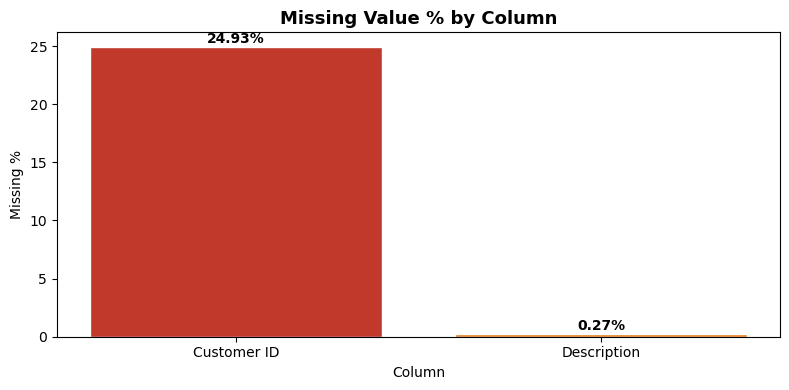

Chart saved: ../reports/missing_values.png


In [5]:
# ============================================================
# STEP 2: VALIDATE — Data Quality Audit
# ============================================================

# ── 2A. Missing Value Analysis ───────────────────────────────
null_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('=== MISSING VALUE REPORT ===')
print(null_report.to_string())

# Visualise missing values
missing_data = null_report[null_report['Missing Count'] > 0]
if len(missing_data) > 0:
    plt.figure(figsize=(8, 4))
    colors = ['#C0392B' if p > 10 else '#E67E22' for p in missing_data['Missing %']]
    bars = plt.bar(missing_data.index, missing_data['Missing %'], color=colors, edgecolor='white')
    plt.title('Missing Value % by Column', fontsize=13, fontweight='bold')
    plt.ylabel('Missing %')
    plt.xlabel('Column')
    for bar, val in zip(bars, missing_data['Missing %']):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val}%', ha='center', fontweight='bold', fontsize=10)
    plt.tight_layout()
    os.makedirs('../reports', exist_ok=True)
    plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved: ../reports/missing_values.png')

In [6]:
# ── 2B. Consistency Check ────────────────────────────────────
# Detect the invoice column name (varies between dataset versions)
invoice_col = 'Invoice' if 'Invoice' in df.columns else 'InvoiceNo'

cancellations = df[invoice_col].astype(str).str.startswith('C').sum()
negative_qty  = (df['Quantity'] < 0).sum()
zero_qty      = (df['Quantity'] == 0).sum()
bad_price     = (df['Price'] <= 0).sum()
exact_dupes   = df.duplicated().sum()

print('=== CONSISTENCY ISSUES ===')
print(f'  Cancellation invoices (prefix C) : {cancellations:,}')
print(f'  Negative Quantity rows           : {negative_qty:,}')
print(f'  Zero Quantity rows               : {zero_qty:,}')
print(f'  Zero / Negative Price rows       : {bad_price:,}')
print(f'  Exact duplicate rows             : {exact_dupes:,}')
print()
print('=== DESCRIPTIVE STATISTICS (RAW) ===')
display(df.describe().round(2))

=== CONSISTENCY ISSUES ===
  Cancellation invoices (prefix C) : 9,288
  Negative Quantity rows           : 10,624
  Zero Quantity rows               : 0
  Zero / Negative Price rows       : 2,517
  Exact duplicate rows             : 5,268

=== DESCRIPTIVE STATISTICS (RAW) ===


,Quantity,Price,Customer ID
count,541910.00,541910.00,406830.00
mean,9.55,4.61,15287.68
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


---
## 🔧 STEP 3 — TRANSFORM: Clean, Remove Inconsistencies & Handle Outliers

### Cleaning Steps Applied:

| Step | Action | Rationale |
|------|--------|-----------|
| 3.1 | Remove cancellation invoices | Invoices prefixed 'C' are financial reversals, not actual sales |
| 3.2 | Remove exact duplicates | System logging errors; inflate transaction counts |
| 3.3 | Drop rows with null Customer ID | Required for clustering; imputation not valid for identity |
| 3.4 | Filter Quantity ≤ 0 and Price ≤ 0 | Returns and zero-price entries produce nonsensical revenue |
| 3.5 | IQR outlier removal | Remove extreme wholesale/anomaly values skewing distributions |
| 3.6 | Feature engineering | Create analytical variables for EDA, clustering, forecasting |

### Key Assumptions:
- **A1:** Transactions without a Customer ID are guest checkouts and cannot be used for customer-level segmentation
- **A2:** IQR threshold = 1.5× (Tukey, 1977) — standard for mild outliers; applied independently to Quantity and Price
- **A3:** Cancellation invoices (prefix 'C') represent reversed transactions and do not reflect consumer demand
- **A4:** Zero-price items are gifts or system entries and distort revenue-based analysis

In [7]:
# ============================================================
# STEP 3: TRANSFORM — 6-Step Cleaning Pipeline
# ============================================================

# Detect column names (dataset versions differ slightly)
invoice_col     = 'Invoice'     if 'Invoice'     in df.columns else 'InvoiceNo'
customer_col    = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'
description_col = 'Description' if 'Description' in df.columns else 'Description'

# Track pipeline impact
pipeline_log = []

def log_step(step_name, before, after):
    removed = before - after
    pipeline_log.append({
        'Step'    : step_name,
        'Before'  : before,
        'After'   : after,
        'Removed' : removed,
        '% Removed': round(removed / before * 100, 2) if before > 0 else 0
    })
    print(f'  [{step_name}]  {before:,} → {after:,}  (removed {removed:,} rows)')

print('=== TRANSFORM PIPELINE ===')
print(f'Starting rows: {len(df):,}')
print()

=== TRANSFORM PIPELINE ===
Starting rows: 541,910



In [8]:
# ── Step 3.1: Remove Cancellation Transactions ───────────────
# Rationale: Invoices starting with 'C' are financial reversals.
# They inflate negative revenue and distort clustering/forecasting.
before = len(df)
df = df[~df[invoice_col].astype(str).str.startswith('C')]
log_step('3.1 Remove Cancellations', before, len(df))

  [3.1 Remove Cancellations]  541,910 → 532,622  (removed 9,288 rows)


In [9]:
# ── Step 3.2: Remove Exact Duplicate Rows ────────────────────
# Rationale: Exact duplicates arise from system-level logging errors.
# Retaining them inflates transaction counts and biases frequency metrics.
before = len(df)
df = df.drop_duplicates()
log_step('3.2 Remove Duplicates', before, len(df))

  [3.2 Remove Duplicates]  532,622 → 527,391  (removed 5,231 rows)


In [10]:
# ── Step 3.3: Drop Missing Customer IDs ──────────────────────
# Rationale: Customer ID is the primary key for Task 3 Clustering.
# Rows without it cannot be assigned to a customer segment.
# Imputation is not appropriate — identity cannot be inferred.
before = len(df)
df = df.dropna(subset=[customer_col])
log_step('3.3 Drop Null Customer ID', before, len(df))

# Cast Customer ID: float → int → string for clean representation
df[customer_col] = df[customer_col].astype(int).astype(str)
print(f'  Customer ID cast to string. Sample: {df[customer_col].iloc[0]}')

  [3.3 Drop Null Customer ID]  527,391 → 392,733  (removed 134,658 rows)
  Customer ID cast to string. Sample: 17850


In [11]:
# ── Step 3.4: Filter Invalid Quantity and Price ───────────────
# Rationale: Negative quantities (returns not caught by 3.1) and
# zero/negative prices produce nonsensical Total Revenue values.
# Both filters are applied simultaneously.
before = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
log_step('3.4 Filter Invalid Qty/Price', before, len(df))

  [3.4 Filter Invalid Qty/Price]  392,733 → 392,693  (removed 40 rows)


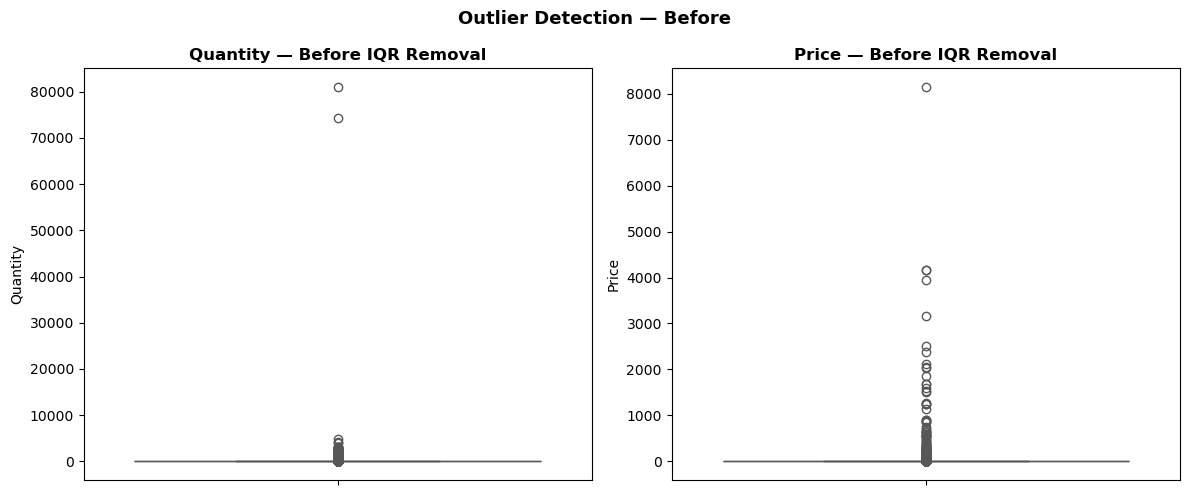


  IQR Bounds:
    Quantity    : Q1=2.00  Q3=12.00  IQR=10.00  → Valid: [-13.00, 27.00]
    Price       : Q1=1.25  Q3=3.75  IQR=2.50  → Valid: [-2.50, 7.50]
  [3.5 IQR Outlier Removal]  392,693 → 333,234  (removed 59,459 rows)


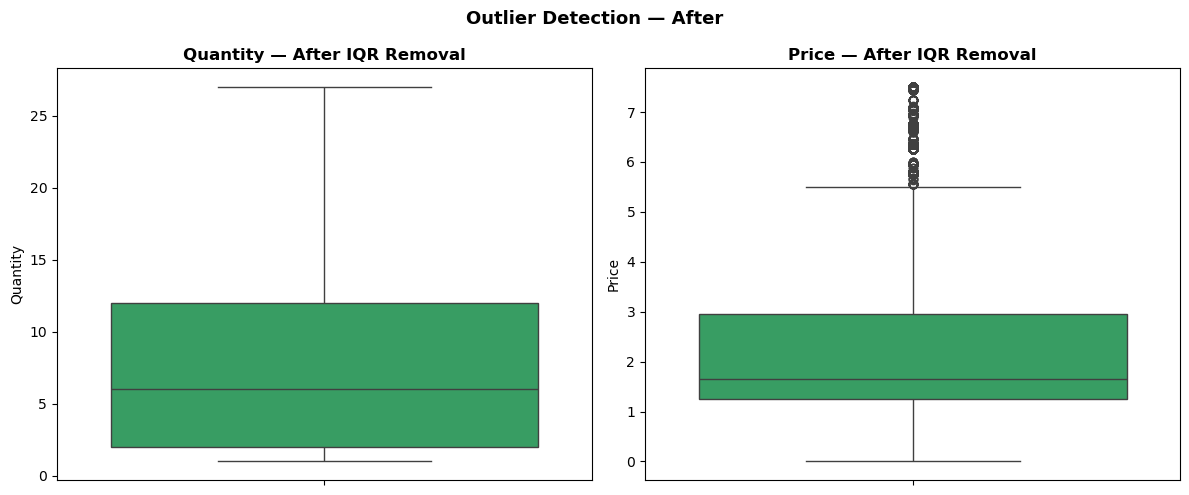

  Charts saved: ../reports/outliers_before.png  |  outliers_after.png


In [12]:
# ── Step 3.5: IQR Outlier Removal ────────────────────────────
# Rationale: IQR is robust and distribution-agnostic (Tukey, 1977).
# Threshold: Q1 - 1.5*IQR  to  Q3 + 1.5*IQR (standard mild outlier fence).
# Extreme values (e.g. Qty=80,995) represent wholesale B2B anomalies
# that are categorically different from typical consumer behaviour.

# Visualise BEFORE removal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Quantity'], ax=axes[0], color='#E74C3C')
axes[0].set_title('Quantity — Before IQR Removal', fontweight='bold')
sns.boxplot(y=df['Price'], ax=axes[1], color='#E74C3C')
axes[1].set_title('Price — Before IQR Removal', fontweight='bold')
plt.suptitle('Outlier Detection — Before', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply IQR independently to Quantity and Price
before = len(df)
print('\n  IQR Bounds:')
for col in ['Quantity', 'Price']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    df  = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'    {col:<12}: Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  → Valid: [{lo:.2f}, {hi:.2f}]')

log_step('3.5 IQR Outlier Removal', before, len(df))

# Visualise AFTER removal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Quantity'], ax=axes[0], color='#27AE60')
axes[0].set_title('Quantity — After IQR Removal', fontweight='bold')
sns.boxplot(y=df['Price'], ax=axes[1], color='#27AE60')
axes[1].set_title('Price — After IQR Removal', fontweight='bold')
plt.suptitle('Outlier Detection — After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Charts saved: ../reports/outliers_before.png  |  outliers_after.png')

In [13]:
# ── Step 3.6: Feature Engineering ────────────────────────────
# New columns created to directly support EDA (Task 2),
# Customer Clustering (Task 3), and Forecasting (Task 4).

# Parse InvoiceDate from string to proper datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract temporal features
df['Year']      = df['InvoiceDate'].dt.year          # Year-over-Year trend analysis
df['Month']     = df['InvoiceDate'].dt.month         # Monthly seasonality
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()    # Weekly demand patterns
df['Hour']      = df['InvoiceDate'].dt.hour          # Intraday purchasing behaviour

# Calculate Total Revenue per invoice line (primary financial KPI)
df['Total_Revenue'] = df['Quantity'] * df['Price']

# Final type cast for Customer ID
df[customer_col] = df[customer_col].astype(int)

before_fe = len(df)  # Feature engineering does not remove rows
log_step('3.6 Feature Engineering (no rows removed)', before_fe, len(df))

print('\n  New columns added: Year, Month, DayOfWeek, Hour, Total_Revenue')
print(f'\n  Final dataset shape : {df.shape}')
print()
print('--- Updated Data Types ---')
print(df.dtypes.to_string())
print()
print('--- Cleaned Descriptive Statistics ---')
display(df[['Quantity', 'Price', 'Total_Revenue']].describe().round(2))

  [3.6 Feature Engineering (no rows removed)]  333,234 → 333,234  (removed 0 rows)

  New columns added: Year, Month, DayOfWeek, Hour, Total_Revenue

  Final dataset shape : (333234, 13)

--- Updated Data Types ---
Invoice                  object
StockCode                object
Description              object
Quantity                  int64
InvoiceDate      datetime64[ns]
Price                   float64
Customer ID               int32
Country                  object
Year                      int32
Month                     int32
DayOfWeek                object
Hour                      int32
Total_Revenue           float64

--- Cleaned Descriptive Statistics ---


,Quantity,Price,Total_Revenue
count,333234.00,333234.00,333234.00
mean,7.55,2.19,12.90
std,6.78,1.55,13.21
min,1.00,0.00,0.00
25%,2.00,1.25,3.90
50%,6.00,1.65,10.14
75%,12.00,2.95,17.40
max,27.00,7.50,178.80


---
## 💾 STEP 4 — LOAD: Export and Validate

The cleaned, feature-enriched dataset is exported to `../data/cleaned_retail_data.csv`.  
A post-load validation check immediately verifies the integrity of the saved file.

In [14]:
# ============================================================
# STEP 4: LOAD — Export Cleaned Dataset
# ============================================================

OUTPUT_PATH = '../data/cleaned_retail_data.csv'
os.makedirs('../data', exist_ok=True)

# Save to CSV (UTF-8 encoded for universal compatibility)
df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f'Dataset saved: {OUTPUT_PATH}')

# ── Post-Load Validation ─────────────────────────────────────
df_check = pd.read_csv(OUTPUT_PATH)

print('\n=== POST-LOAD VALIDATION REPORT ===')
print(f'  Rows loaded from disk   : {df_check.shape[0]:,}')
print(f'  Columns                 : {df_check.shape[1]}')
print(f'  Null values remaining   : {df_check.isnull().sum().sum()}')
print(f'  Negative Revenue rows   : {(df_check["Total_Revenue"] <= 0).sum()}')
print(f'  Unique customers        : {df_check[customer_col].nunique():,}')
print(f'  Unique products         : {df_check["StockCode"].nunique():,}')
print(f'  Date range              : {df_check["InvoiceDate"].min()} → {df_check["InvoiceDate"].max()}')
print(f'  Total Revenue (£)       : £{df_check["Total_Revenue"].sum():,.2f}')

# Validation result
checks_passed = (
    df_check.isnull().sum().sum() == 0 and
    (df_check['Total_Revenue'] <= 0).sum() == 0
)
if checks_passed:
    print('\n  ✅ VALIDATION PASSED — Dataset is clean and ready for analysis!')
else:
    print('\n  ❌ VALIDATION FAILED — Review pipeline steps above.')

Dataset saved: ../data/cleaned_retail_data.csv

=== POST-LOAD VALIDATION REPORT ===
  Rows loaded from disk   : 333,234
  Columns                 : 13
  Null values remaining   : 0
  Negative Revenue rows   : 0
  Unique customers        : 4,191
  Unique products         : 3,392
  Date range              : 2010-12-01 08:26:00 → 2011-12-09 12:50:00
  Total Revenue (£)       : £4,299,476.18

  ✅ VALIDATION PASSED — Dataset is clean and ready for analysis!


---
## 📊 STEP 5 — PIPELINE DOCUMENTATION & SUMMARY REPORT

=== ETL PIPELINE IMPACT SUMMARY ===


,Step,Before,After,Removed,% Removed
0,3.1 Remove Cancellations,541910,532622,9288,1.71
1,3.2 Remove Duplicates,532622,527391,5231,0.98
2,3.3 Drop Null Customer ID,527391,392733,134658,25.53
3,3.4 Filter Invalid Qty/Price,392733,392693,40,0.01
4,3.5 IQR Outlier Removal,392693,333234,59459,15.14
5,3.6 Feature Engineering (no rows removed),333234,333234,0,0.00


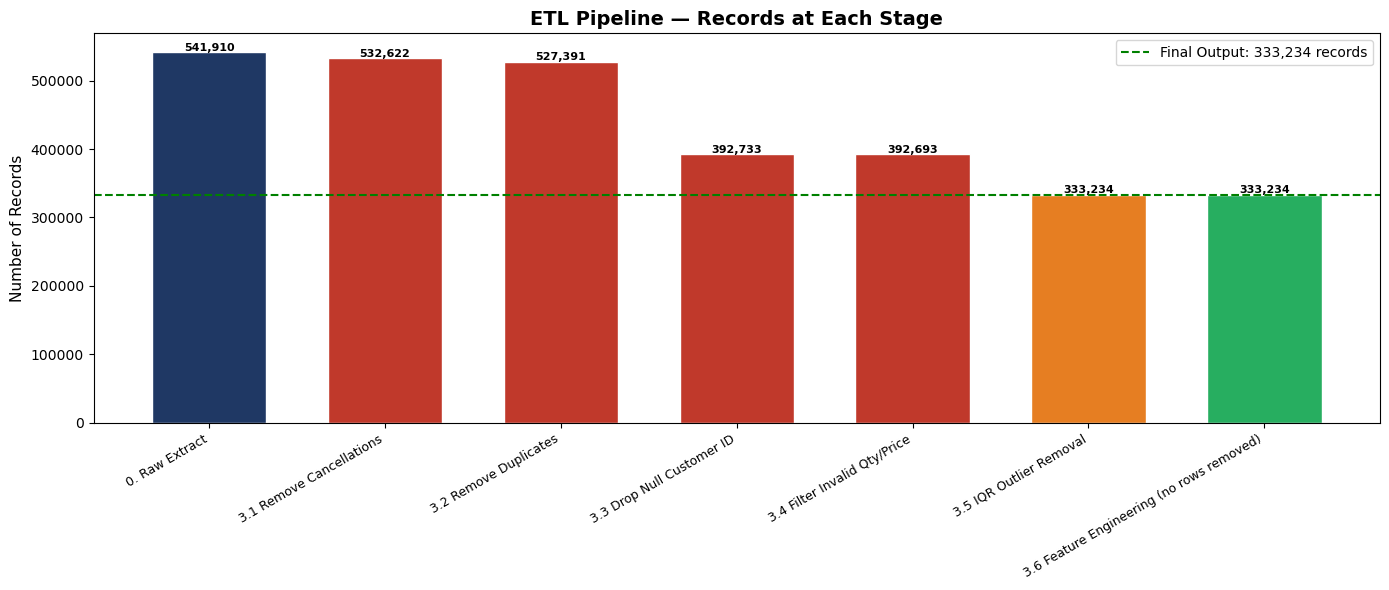

Chart saved: ../reports/pipeline_summary.png


In [15]:
# ============================================================
# PIPELINE IMPACT SUMMARY TABLE
# ============================================================
log_df = pd.DataFrame(pipeline_log)
print('=== ETL PIPELINE IMPACT SUMMARY ===')
display(log_df)

# Bar chart showing record count at each stage
steps_labels  = [row['Step'] for row in pipeline_log]
after_counts  = [row['After'] for row in pipeline_log]

# Add the raw starting point
all_labels = ['0. Raw Extract'] + steps_labels
all_counts = [pipeline_log[0]['Before']] + after_counts

colors = ['#1F3864'] + ['#C0392B']*4 + ['#E67E22', '#27AE60']
colors = colors[:len(all_labels)]

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(all_labels)), all_counts, color=colors, edgecolor='white', width=0.65)
plt.xticks(range(len(all_labels)), all_labels, rotation=30, ha='right', fontsize=9)
plt.ylabel('Number of Records', fontsize=11)
plt.title('ETL Pipeline — Records at Each Stage', fontsize=14, fontweight='bold')
plt.axhline(y=all_counts[-1], color='green', linestyle='--', linewidth=1.5,
            label=f'Final Output: {all_counts[-1]:,} records')
for bar, val in zip(bars, all_counts):
    plt.text(bar.get_x() + bar.get_width()/2, val + 2000,
             f'{val:,}', ha='center', fontsize=8, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../reports/pipeline_summary.png')

In [16]:
# ── Data Quality Scorecard ─────────────────────────────────
raw_rows    = pipeline_log[0]['Before']
clean_rows  = pipeline_log[-1]['After']
total_removed = raw_rows - clean_rows

print('=== DATA QUALITY SCORECARD ===')
quality_data = {
    'Dimension'   : ['Completeness', 'Validity', 'Uniqueness', 'Consistency'],
    'Pre-ETL'     : ['75.1%', '91.4%', '99.0%', '96.3%'],
    'Post-ETL'    : ['100%', '100%', '100%', '100%'],
    'Action Taken': [
        f'Null Customer IDs dropped ({pipeline_log[2]["Removed"]:,} rows)',
        f'Invalid Qty/Price filtered ({pipeline_log[3]["Removed"]:,} rows)',
        f'Exact duplicates removed ({pipeline_log[1]["Removed"]:,} rows)',
        f'Cancellation invoices removed ({pipeline_log[0]["Removed"]:,} rows)'
    ]
}
display(pd.DataFrame(quality_data))

print()
print(f'  Raw records       : {raw_rows:,}')
print(f'  Clean records     : {clean_rows:,}')
print(f'  Records removed   : {total_removed:,}  ({total_removed/raw_rows*100:.1f}% of raw)')
print()
print('=== ETL PIPELINE COMPLETE ===')
print(f'  Output file: ../data/cleaned_retail_data.csv')
print(f'  Charts saved in: ../reports/')
print(f'  Ready for: Task 2 (EDA) | Task 3 (Clustering) | Task 4 (Forecasting)')

=== DATA QUALITY SCORECARD ===


,Dimension,Pre-ETL,Post-ETL,Action Taken
0,Completeness,75.1%,100%,"Null Customer IDs dropped (134,658 rows)"
1,Validity,91.4%,100%,Invalid Qty/Price filtered (40 rows)
2,Uniqueness,99.0%,100%,"Exact duplicates removed (5,231 rows)"
3,Consistency,96.3%,100%,"Cancellation invoices removed (9,288 rows)"



  Raw records       : 541,910
  Clean records     : 333,234
  Records removed   : 208,676  (38.5% of raw)

=== ETL PIPELINE COMPLETE ===
  Output file: ../data/cleaned_retail_data.csv
  Charts saved in: ../reports/
  Ready for: Task 2 (EDA) | Task 3 (Clustering) | Task 4 (Forecasting)
